# **ЛАБОРАТОРНА РОБОТА 2a**
## Одношаровий персептрон
### 2 варіант

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
import time

## **1. Завантаження та підготовка даних**

In [2]:
data = pd.read_csv("data02.csv", sep=";", header=None)

data.columns = ["x1", "x2", "class"]

print(data.head())

print("\nРозмір датасету:", data.shape)

print("\nРозподіл класів:")
print(data["class"].value_counts())

      x1     x2  class
0  0.107  0.184      0
1  0.804  0.961      1
2  0.605  0.217      1
3  0.973  0.622      1
4  0.717  0.311      1

Розмір датасету: (100, 3)

Розподіл класів:
class
1    53
0    47
Name: count, dtype: int64


In [4]:
X = data[["x1", "x2"]].values
y = data["class"].replace({0: -1, 1: 1}).values

print("X:")
print(X[:5])

print("\ny:")
print(y[:5])

X:
[[0.107 0.184]
 [0.804 0.961]
 [0.605 0.217]
 [0.973 0.622]
 [0.717 0.311]]

y:
[-1  1  1  1  1]


### Розділення даних на навчальну та тестову вибірки

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Навчальна вибірка: (70, 2)
Тестова вибірка: (30, 2)


### Навчальна вибірка даних

In [21]:
print(X_train)

[[0.805 0.116]
 [0.881 0.038]
 [0.966 0.954]
 [0.696 0.42 ]
 [0.807 0.202]
 [0.469 0.569]
 [0.488 0.895]
 [0.857 0.385]
 [0.973 0.622]
 [0.459 0.73 ]
 [0.388 0.713]
 [0.137 0.984]
 [0.563 0.394]
 [0.375 0.899]
 [0.741 0.64 ]
 [0.351 0.865]
 [0.394 0.479]
 [0.107 0.184]
 [0.136 0.222]
 [0.683 0.282]
 [0.102 0.222]
 [0.202 0.235]
 [0.738 0.3  ]
 [0.744 0.361]
 [0.382 0.497]
 [0.103 0.984]
 [0.075 0.044]
 [0.597 0.394]
 [0.445 0.436]
 [0.19  0.507]
 [0.608 0.037]
 [0.219 0.122]
 [0.909 0.949]
 [0.954 0.423]
 [0.31  0.649]
 [0.695 0.166]
 [0.895 0.881]
 [0.804 0.961]
 [0.057 0.481]
 [0.986 0.731]
 [0.961 0.471]
 [0.19  0.056]
 [0.272 0.124]
 [0.795 0.699]
 [0.782 0.139]
 [0.268 0.895]
 [0.78  0.152]
 [0.426 0.336]
 [0.167 0.276]
 [0.893 0.442]
 [0.963 0.557]
 [0.866 0.745]
 [0.567 0.791]
 [0.247 0.258]
 [0.493 0.308]
 [0.484 0.92 ]
 [0.472 0.966]
 [0.742 0.472]
 [0.804 0.059]
 [0.184 0.163]
 [0.886 0.677]
 [0.04  0.593]
 [0.075 0.495]
 [0.356 0.25 ]
 [0.761 0.023]
 [0.031 0.107]
 [0.445 0.

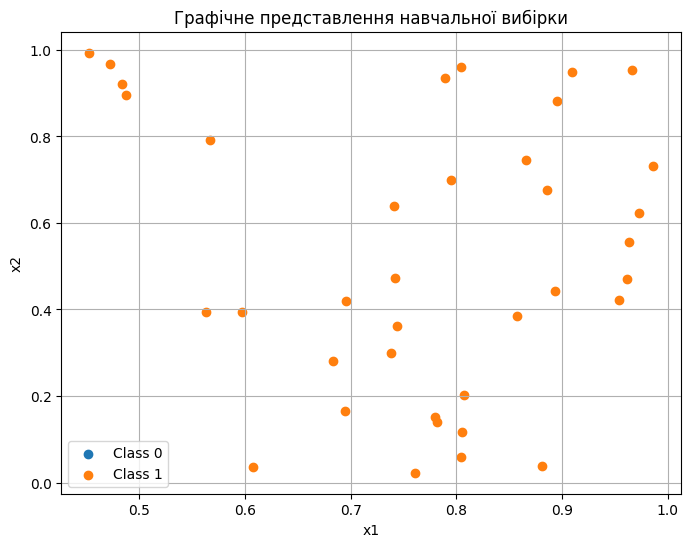

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], label='Class 0')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label='Class 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Графічне представлення навчальної вибірки')
plt.grid(True)
plt.legend()
plt.show()

## **2. Власна реалізація персептрона**

In [ ]:
class MyPerceptron: 
 
    def __init__(self, max_epochs=1000): 
        # Set the maximum number of training epochs
        self.max_epochs = max_epochs 
        
        # Store model weights
        self.weights = None 
        
        # Store the number of errors for each epoch
        self.errors_history = [] 
        
        # Store the number of completed epochs
        self.epochs = 0 
 
    def fit(self, X, y): 
        
        # Add a bias column to the input data
        X_bias = np.c_[X, np.ones(X.shape[0])] 
        
        # Initialize all weights with zeros
        self.weights = np.zeros(X_bias.shape[1]) 
        
        # Clear the error history
        self.errors_history = [] 
 
        # Start the training loop
        for epoch in range(self.max_epochs): 
            
            # Count errors in the current epoch
            errors = 0 
            
            # Shuffle the data indexes
            indices = np.random.permutation(len(X_bias)) 
 
            # Process each training sample
            for i in indices: 
 
                # Calculate the activation value
                activation = np.dot(self.weights, X_bias[i]) 
                
                # Predict the class
                prediction = 1 if activation >= 0 else -1 
 
                # Check if the prediction is wrong
                if prediction != y[i]: 
                    
                    # Update the weights
                    self.weights += y[i] * X_bias[i] 
                    
                    # Increase the error count
                    errors += 1 
 
            # Save the number of errors
            self.errors_history.append(errors) 
            
            # Save the current epoch number
            self.epochs = epoch + 1 
 
            # Stop training if there are no errors
            if errors == 0: 
                break 
 
        # Return the trained model
        return self 
 
    def predict(self, X): 
 
        # Add a bias column to the input data
        X_bias = np.c_[X, np.ones(X.shape[0])] 
        
        # Calculate activation values
        activation = np.dot(X_bias, self.weights) 
 
        # Return the predicted classes
        return np.where(activation >= 0, 1, -1)

In [7]:
my_perceptron = MyPerceptron(max_epochs = 100)

start_time = time.time()
my_perceptron.fit(X_train, y_train)
my_time = time.time() - start_time

print("Кількість епох:", my_perceptron.epochs)
print("Ваги:", my_perceptron.weights)
print("Час навчання:", my_time, "с")

Кількість епох: 6
Ваги: [ 5.302  0.604 -3.   ]
Час навчання: 0.003257274627685547 с


In [8]:
y_train_pred = my_perceptron.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Точність на навчальній вибірці:", train_accuracy)

Точність на навчальній вибірці: 1.0


In [ ]:
y_test_pred = my_perceptron.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Точність на тестовій вибірці:", test_accuracy)

Точність на тестовій вибірці: 1.0


## **3. Реалізація песпетрона за допомогою бібліотеки Scikit-learn**

In [10]:
sklearn_perceptron = Perceptron(
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

start_time = time.time()
sklearn_perceptron.fit(X_train, y_train)
sklearn_time = time.time() - start_time

In [11]:
y_test_pred_sklearn = sklearn_perceptron.predict(X_test)
sklearn_accuracy = accuracy_score(
    y_test,
    y_test_pred_sklearn
)

print("Точність:", sklearn_accuracy)
print("Кількість ітерацій:", sklearn_perceptron.n_iter_)
print("Час навчання:", sklearn_time, "с")
print("Ваги:", sklearn_perceptron.coef_)

Точність: 0.9666666666666667
Кількість ітерацій: 8
Час навчання: 0.012359142303466797 с
Ваги: [[3.482 0.549]]


## **4. Порівняння**

In [12]:
print("\n--- Власний персептрон ---")
print("Ваги:", my_perceptron.weights)
print("Кількість епох:", my_perceptron.epochs)
print("Accuracy test:", test_accuracy)
print("Час:", my_time, "с")

print("\n--- sklearn Perceptron ---")
print("Ваги:", sklearn_perceptron.coef_)
print("Кількість ітерацій:", sklearn_perceptron.n_iter_)
print("Accuracy test:", sklearn_accuracy)
print("Час:", sklearn_time, "с")



--- Власний персептрон ---
Ваги: [ 5.302  0.604 -3.   ]
Кількість епох: 6
Accuracy test: 1.0
Час: 0.003257274627685547 с

--- sklearn Perceptron ---
Ваги: [[3.482 0.549]]
Кількість ітерацій: 8
Accuracy test: 0.9666666666666667
Час: 0.012359142303466797 с


In [13]:
print("Передбачення власного персептрона:")
print(y_test_pred)

print("\nПередбачення sklearn:")
print(y_test_pred_sklearn)

print( "\nКількість однакових передбачень:", np.sum(y_test_pred == y_test_pred_sklearn), "з", len(y_test))

Передбачення власного персептрона:
[ 1 -1  1 -1 -1  1  1  1  1 -1  1  1 -1 -1  1  1 -1 -1  1 -1 -1 -1  1  1
 -1 -1  1  1  1 -1]

Передбачення sklearn:
[ 1 -1  1 -1 -1  1  1  1  1 -1  1  1 -1 -1  1  1  1 -1  1 -1 -1 -1  1  1
 -1 -1  1  1  1 -1]

Кількість однакових передбачень: 29 з 30


### Порівняння графіків класифікації тестової та навчальної вибірки

Text(0.5, 0.98, 'Порівняння класифікації власного та Scikit-learn перцептронів')

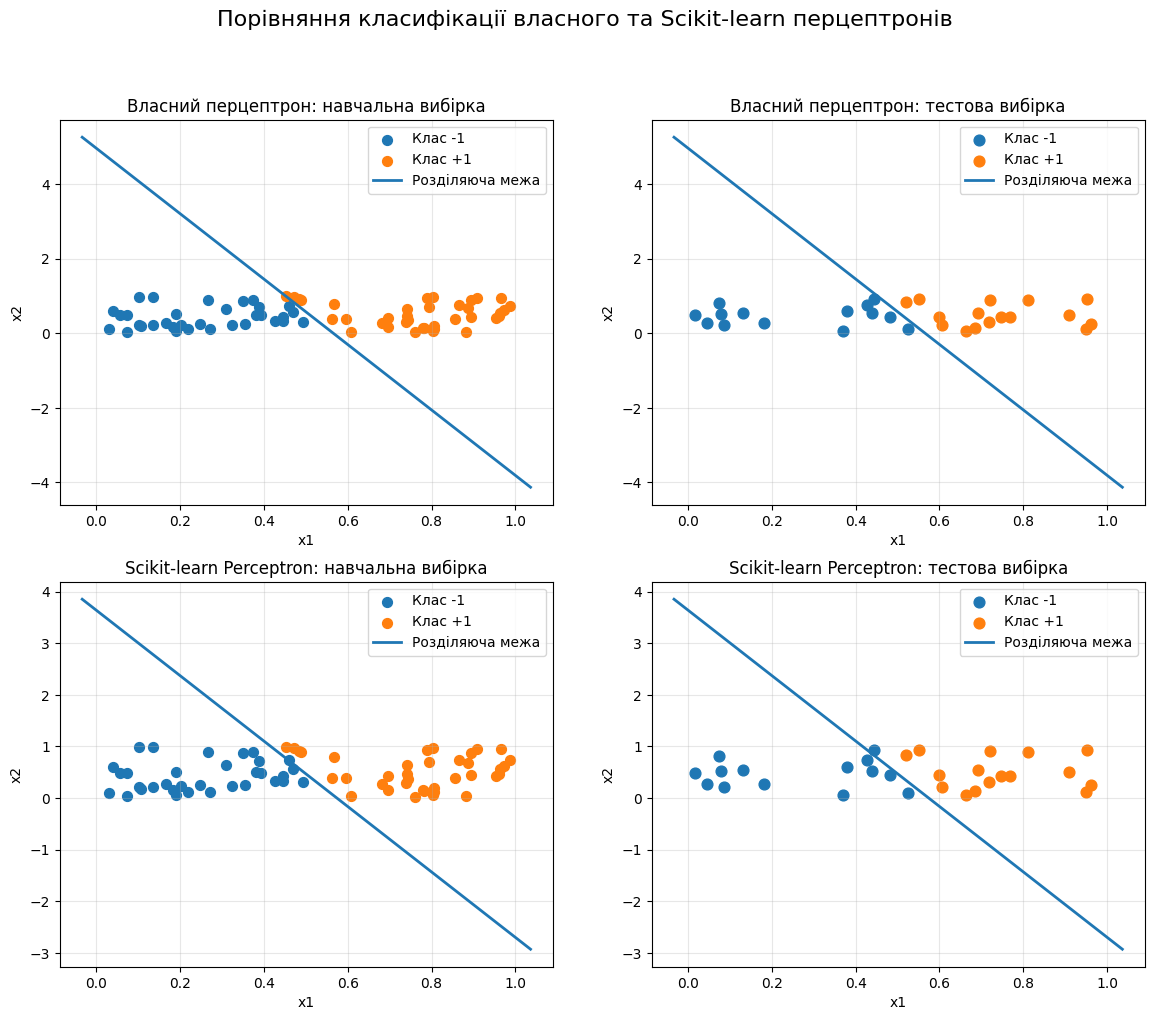

In [ ]:
w1 = my_perceptron.weights[0]
w2 = my_perceptron.weights[1]
b_my = my_perceptron.weights[2]

x_min = X[:, 0].min() - 0.05
x_max = X[:, 0].max() + 0.05

x_line = np.linspace(x_min, x_max, 100)
y_line = -(w1 * x_line + b_my) / w2

w_sklearn = sklearn_perceptron.coef_[0]
b_sklearn = sklearn_perceptron.intercept_[0]

x_line_sklearn = np.linspace(x_min, x_max, 100)
y_line_sklearn = -(w_sklearn[0] * x_line_sklearn + b_sklearn) / w_sklearn[1]


fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], label="Клас -1", s=50)
axes[0, 0].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label="Клас +1", s=50)
axes[0, 0].plot(x_line, y_line, linewidth=2, label="Розділяюча межа")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")
axes[0, 0].set_title("Власний перцептрон: навчальна вибірка")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1], label="Клас -1", s=60)
axes[0, 1].scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], label="Клас +1", s=60)
axes[0, 1].plot(x_line, y_line, linewidth=2, label="Розділяюча межа")
axes[0, 1].set_xlabel("x1")
axes[0, 1].set_ylabel("x2")
axes[0, 1].set_title("Власний перцептрон: тестова вибірка")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], label="Клас -1", s=50)
axes[1, 0].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label="Клас +1", s=50)
axes[1, 0].plot(x_line_sklearn, y_line_sklearn, linewidth=2, label="Розділяюча межа")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")
axes[1, 0].set_title("Scikit-learn Perceptron: навчальна вибірка")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(X_test[y_test == -1, 0], X_test[y_test == -1, 1], label="Клас -1", s=60)
axes[1, 1].scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], label="Клас +1", s=60)
axes[1, 1].plot(x_line_sklearn, y_line_sklearn, linewidth=2, label="Розділяюча межа")
axes[1, 1].set_xlabel("x1")
axes[1, 1].set_ylabel("x2")
axes[1, 1].set_title("Scikit-learn Perceptron: тестова вибірка")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Порівняння класифікації власного та Scikit-learn персептронів", fontsize=16)

### Порівняння графіків збіжності

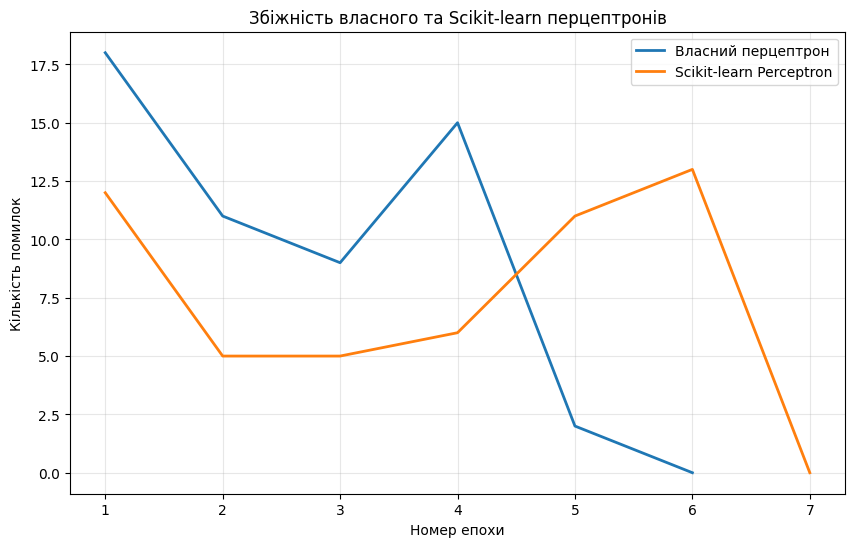

In [ ]:
my_errors = my_perceptron.errors_history

sklearn_history = []
sklearn_model = Perceptron(random_state=42)
for epoch in range(1000):
    sklearn_model.partial_fit(X_train, y_train, classes=np.array([-1, 1]))
    
    y_pred = sklearn_model.predict(X_train)
    errors = np.sum(y_pred != y_train)
    sklearn_history.append(errors)
    
    if errors == 0:
        break

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(my_errors) + 1), my_errors, linewidth=2, label="Власний персептрон")
plt.plot(range(1, len(sklearn_history) + 1), sklearn_history, linewidth=2, label="Scikit-learn Perceptron")

plt.xlabel("Номер епохи")
plt.ylabel("Кількість помилок")
plt.title("Збіжність власного та Scikit-learn персептронів")
plt.legend()
plt.grid(True, alpha=0.3)

### Порівняння часу

In [16]:
models = ["MyPerceptron", "sklearn Perceptron"]

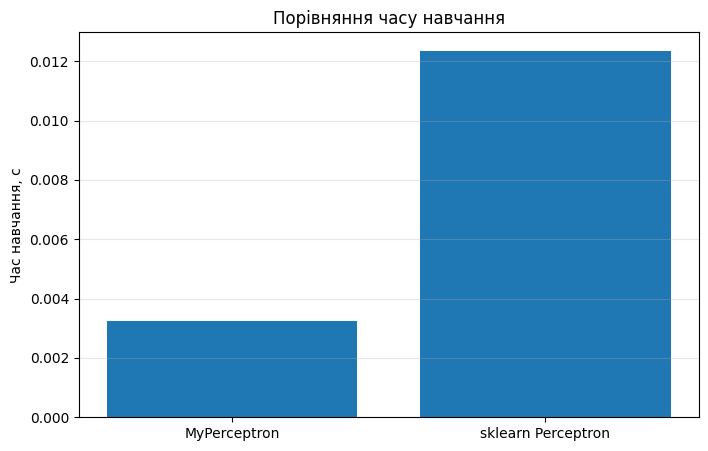

In [17]:
times = [my_time, sklearn_time]

plt.figure(figsize=(8, 5))
plt.bar(models, times)
plt.ylabel("Час навчання, с")
plt.title("Порівняння часу навчання")
plt.grid(axis="y", alpha=0.3)

### Порівняння кількості ітерацій

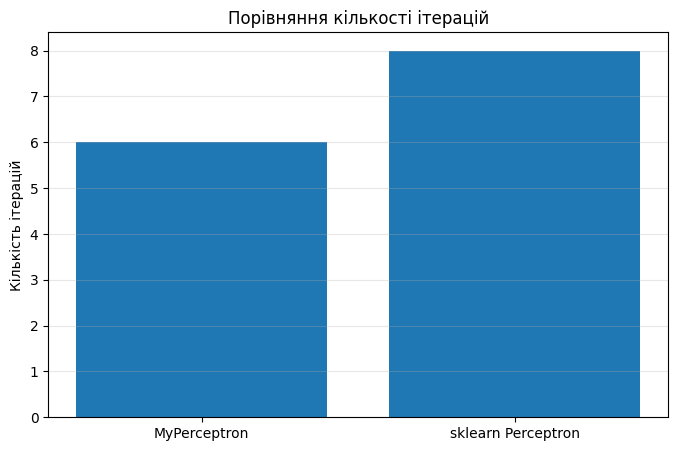

In [18]:
iterations = [my_perceptron.epochs, sklearn_perceptron.n_iter_]

plt.figure(figsize=(8, 5))
plt.bar(models, iterations)
plt.ylabel("Кількість ітерацій")
plt.title("Порівняння кількості ітерацій")
plt.grid(axis="y", alpha=0.3)